<a href="https://colab.research.google.com/github/jagadeeshdandu/NASSCOM-AI-FDP/blob/main/NASSCOM_Day_2_Linear_Algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [2]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [3]:
# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [8]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)


T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [10]:
print(f'T ndim={T.ndim}  shape={T.shape}')

T ndim=2  shape=(3, 4)


In [12]:
result_T_plus_T = T + T
print('T + T:\n', result_T_plus_T)


T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]


In [13]:
print('T.T (transpose -> shape', T.T.shape, '):\n', T.T)
print('T.reshape(2, 6):\n', T.reshape(2, 6))

T.T (transpose -> shape (4, 3) ):
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
T.reshape(2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [15]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [16]:
# -----------------------------------------------------------
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
# -----------------------------------------------------------

print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [21]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
  print('L2 norm  ||u||_2 :', la.norm(u))       # Euclidean norm
  print('L1 norm  ||u||_1 :', la.norm(u, 1))    # Manhattan norm
  print(f'cosine(pair {i})    : {round(cosine(u, v), 3)}')
  pass


L2 norm  ||u||_2 : 1.4142135623730951
L1 norm  ||u||_1 : 2.0
cosine(pair 1)    : 1.0
L2 norm  ||u||_2 : 3.7416573867739413
L1 norm  ||u||_1 : 6.0
cosine(pair 2)    : 0.714
L2 norm  ||u||_2 : 2.0
L1 norm  ||u||_1 : 2.0
cosine(pair 3)    : 0.0


In [22]:
# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [23]:
# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [ ]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation


In [25]:
M = np.array([[4., 2.],
              [2., 3.]])
print('inverse(M):\n', la.inv(M))
print('trace(M) = sum of diagonal:', np.trace(M))

inverse(M):
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
trace(M) = sum of diagonal: 7.0


In [26]:
print('M @ inv(M) == I ?', np.allclose(M @ la.inv(M), I))

M @ inv(M) == I ? True


In [28]:
P = np.array([[0., -1.],
              [1.,  0.]])
print('M symmetric?', np.allclose(M, M.T))
print('P orthogonal?', np.allclose(P.T @ P, I))

M symmetric? True
P orthogonal? True


In [29]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


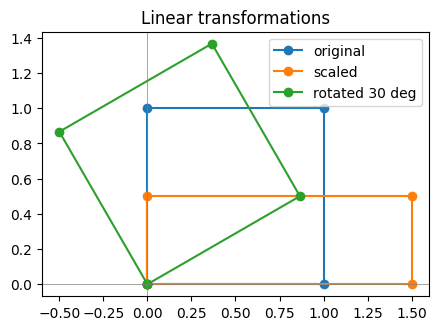

In [30]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

In [31]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

### Apply a new scaling transformation to the triangle

In [32]:
# Scaling matrix: stretch x by 2, y by 0.5
S_new = np.array([[2.0, 0.0],
                  [0.0, 0.5]])

scaled_tri = S_new @ tri
print('Scaled triangle corners:\n', scaled_tri)

Scaled triangle corners:
 [[0.  2.  1. ]
 [0.  0.  0.5]]


### Plotting Original vs. Scaled Triangle

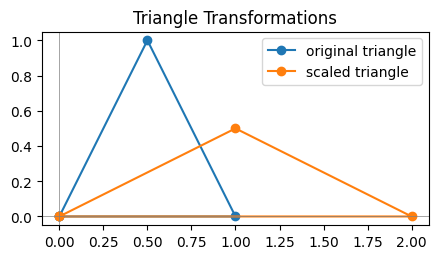

In [33]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(tri),  marker='o', label='original triangle')
ax.plot(*close_loop(scaled_tri),  marker='o', label='scaled triangle')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Triangle Transformations')
plt.show()

### Apply a rotation transformation (45 degrees) to the triangle

In [34]:
# Rotation matrix: rotate by 45 degrees
t_45 = np.radians(45)
R_new = np.array([[np.cos(t_45), -np.sin(t_45)],
                  [np.sin(t_45),  np.cos(t_45)]])

rotated_tri = R_new @ tri
print('Rotated triangle corners (45 degrees):\n', rotated_tri)

Rotated triangle corners (45 degrees):
 [[ 0.     0.707 -0.354]
 [ 0.     0.707  1.061]]


### Plotting Original vs. Rotated Triangle (45 degrees)

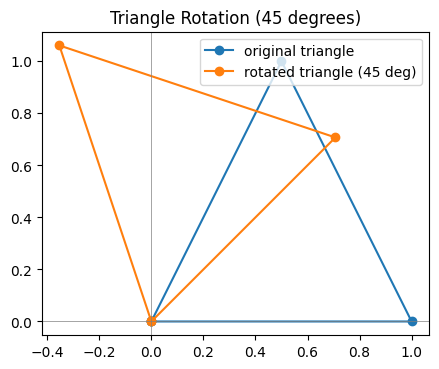

In [35]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(tri),  marker='o', label='original triangle')
ax.plot(*close_loop(rotated_tri),  marker='o', label='rotated triangle (45 deg)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Triangle Rotation (45 degrees)')
plt.show()

### Plotting Original vs. Scaled vs. Rotated Triangle

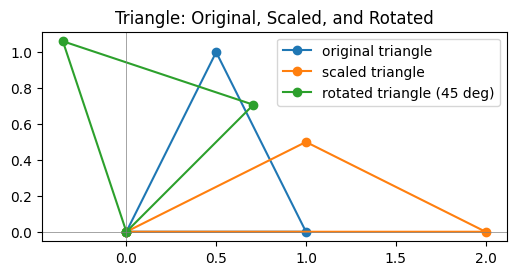

In [36]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(*close_loop(tri),  marker='o', label='original triangle')
ax.plot(*close_loop(scaled_tri),  marker='o', label='scaled triangle')
ax.plot(*close_loop(rotated_tri), marker='o', label='rotated triangle (45 deg)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Triangle: Original, Scaled, and Rotated')
plt.show()

In [37]:
# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]


In [38]:
# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))

lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [39]:
C = np.array([[4., 1.],
              [2., 3.]])

# -----------------------------------------------------------
# 🔹 5C. COMPUTE EIGENVALUES & EIGENVECTORS for C
# -----------------------------------------------------------

In [40]:
vals_C, vecs_C = la.eig(C)     # vals_C = eigenvalues, vecs_C columns = eigenvectors
print('Eigenvalues  (lambda) for C:', vals_C)
print('Eigenvectors (columns) for C:\n', vecs_C)

Eigenvalues  (lambda) for C: [5. 2.]
Eigenvectors (columns) for C:
 [[ 0.707 -0.447]
 [ 0.707  0.894]]


# -----------------------------------------------------------
# 🔹 5D. VERIFY C v = lambda v for C
# -----------------------------------------------------------

In [41]:
for i in range(len(vals_C)):
    v_C = vecs_C[:, i]                 # i-th eigenvector
    lhs_C = C @ v_C                    # C v
    rhs_C = vals_C[i] * v_C              # lambda v
    print(f'lambda={vals_C[i]:.1f}  C v == lambda v ?', np.allclose(lhs_C, rhs_C))

lambda=5.0  C v == lambda v ? True
lambda=2.0  C v == lambda v ? True


In [42]:
print('Eigenvalues of C:', vals_C)

Eigenvalues of C: [5. 2.]


### Verify `A v = lambda v` for the first eigenvector of matrix A

In [43]:
first_eigenvalue = vals[0]
first_eigenvector = vecs[:, 0]

lhs_first = A @ first_eigenvector
rhs_first = first_eigenvalue * first_eigenvector

print(f'First eigenvalue (lambda): {first_eigenvalue:.1f}')
print(f'First eigenvector (v): {first_eigenvector}')
print(f'A @ v: {lhs_first}')
print(f'lambda * v: {rhs_first}')
print(f'A v == lambda v ? {np.allclose(lhs_first, rhs_first)}')


First eigenvalue (lambda): 2.0
First eigenvector (v): [1. 0.]
A @ v: [2. 0.]
lambda * v: [2. 0.]
A v == lambda v ? True


In [44]:
# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')


Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [45]:
# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Rank of D: 2 -> < 3, so rows are dependent


In [46]:
# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low

cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [47]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])


# -----------------------------------------------------------
# 🔹 6D. SOLVE A 2x2 SYSTEM A2 x = b2
# -----------------------------------------------------------

In [48]:
x2 = la.solve(A2, b2)
print('Solution x for A2 x = b2:', x2)

Solution x for A2 x = b2: [1. 2.]


In [49]:
print('Rank of A2:', la.matrix_rank(A2))

Rank of A2: 2


In [50]:
cosine_cat_dog = cosine(cat, dog)
cosine_cat_car = cosine(cat, car)

print(f'Cosine(cat, dog): {cosine_cat_dog:.3f}')
print(f'Cosine(cat, car): {cosine_cat_car:.3f}')

if cosine_cat_dog > cosine_cat_car:
    print('The pair (cat, dog) is more similar.')
else:
    print('The pair (cat, car) is more similar.')

Cosine(cat, dog): 0.995
Cosine(cat, car): 0.293
The pair (cat, dog) is more similar.
